In [10]:

import pandas as pd

# Load the dataset
df = pd.read_csv("Processed_Reviews.csv")

# 1. Use only the lemmatized column and the label
df = df[['lemmatized', 'label']]

print(df.head(13))


                                           lemmatized  label
0   product arrive time packaging great quality am...    1.0
1                                  product amaze love    1.0
2                  buy phone hz display totally worth    1.0
3                   wow product awesome bit expensive    0.0
4                          laptop work perfectly fine    1.0
5                           check full product detail    0.0
6                        great purchase happy product    1.0
7           battery life excellent charge cable short    0.0
8                 can not believe good expect quality    1.0
9          love product fast delivery amazing quality    1.0
10                  honest expect much oh god awesome    1.0
11                         best product ever use life    1.0
12     shoe comfortable fit nicely work perfectly jog    1.0


In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Vectorize the lemmatized text
tfidf_vect = TfidfVectorizer()
X = tfidf_vect.fit_transform(df['lemmatized']) 
y = df['label']

In [18]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Split data into train & test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

# Train Naive Bayes
nb_clf = MultinomialNB().fit(X_train, y_train)

# Train SVM
svm_clf = SVC(kernel='linear').fit(X_train, y_train)

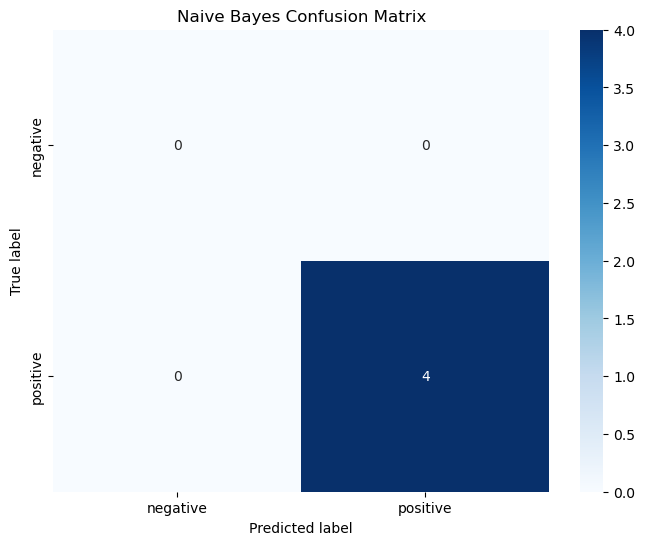

Naive Bayes Classifier Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

Naive Bayes Error Rate: 0.00


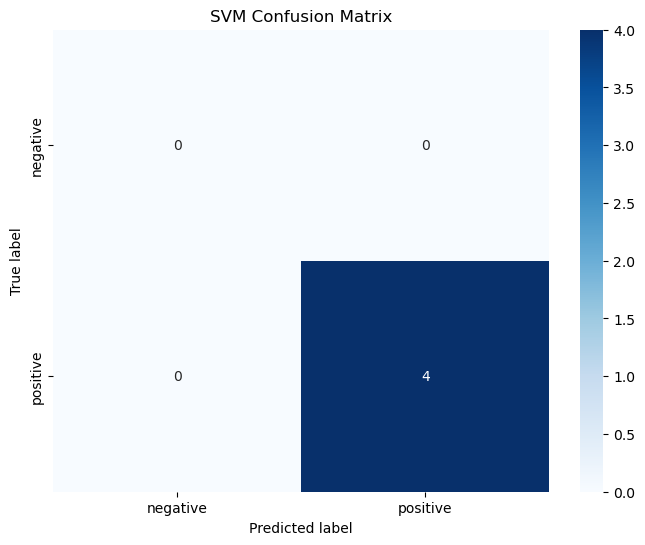


SVM Classifier Report:
              precision    recall  f1-score   support

         1.0       1.00      1.00      1.00         4

    accuracy                           1.00         4
   macro avg       1.00      1.00      1.00         4
weighted avg       1.00      1.00      1.00         4

SVM Error Rate: 0.00


In [19]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Naive Bayes Evaluation ---
nb_predicted = nb_clf.predict(X_test)
nb_report = classification_report(y_test, nb_predicted)
nb_error_rate = 1 - accuracy_score(y_test, nb_predicted)
# FIX: Added labels=[0, 1] to ensure a 2x2 matrix even with small data
nb_cm = confusion_matrix(y_test, nb_predicted, labels=[0, 1])

# --- SVM Evaluation ---
svm_predicted = svm_clf.predict(X_test)
svm_report = classification_report(y_test, svm_predicted)
svm_error_rate = 1 - accuracy_score(y_test, svm_predicted)
# FIX: Added labels=[0, 1] to ensure a 2x2 matrix even with small data
svm_cm = confusion_matrix(y_test, svm_predicted, labels=[0, 1])

# --- Visualization Function ---
def plot_confusion_matrix(cm, classes, title='Confusion matrix', cmap=plt.cm.Blues):
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, xticklabels=classes, yticklabels=classes)
    plt.title(title)
    plt.xlabel('Predicted label')
    plt.ylabel('True label')
    plt.show()

# Plot & Print Results for Naive Bayes
plot_confusion_matrix(nb_cm, classes=['negative', 'positive'], title='Naive Bayes Confusion Matrix')
print("Naive Bayes Classifier Report:")
print(nb_report)
print(f"Naive Bayes Error Rate: {nb_error_rate:.2f}")

# Plot & Print Results for SVM
plot_confusion_matrix(svm_cm, classes=['negative', 'positive'], title='SVM Confusion Matrix')
print("\nSVM Classifier Report:")
print(svm_report)
print(f"SVM Error Rate: {svm_error_rate:.2f}")